<a href="https://colab.research.google.com/github/siamabdurrahman/Brain-Tumour-Classification/blob/Brain_tumour_classification/Brain_tumour_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


*Project Folders*

In [3]:
import os

base_path = "/content/drive/MyDrive/brain_tumour_project"

folders = [
    "data",
    "figures",
    "results",
    "saved_models",
    "report_notes"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


*Upload and unzip the dataset*

In [4]:
import zipfile
import os

zip_path = "/content/archive.zip" # Make sure to upload archive.zip to the /content/ folder
extract_path = os.path.join(base_path, "data")

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully.")
else:
    print(f"Error: File not found at {zip_path}. Please upload the dataset to Colab session storage.")

Dataset extracted successfully.


*Check the dataset folders*

In [5]:
dataset_root = os.path.join(base_path, "data", "Brain (y-n)", "Training")

for item in os.listdir(dataset_root):
    print(item)

no
yes


*Count the number of images in each class*

In [6]:
yes_path = os.path.join(dataset_root, "yes")
no_path = os.path.join(dataset_root, "no")

yes_count = len(os.listdir(yes_path))
no_count = len(os.listdir(no_path))
total_count = yes_count + no_count

print("Yes images:", yes_count)
print("No images:", no_count)
print("Total images:", total_count)

Yes images: 2725
No images: 2725
Total images: 5450


*Report Note*

In [7]:
notes_path = os.path.join(base_path, "report_notes", "01_dataset_description.txt")

notes_text = f"""
Dataset name: Brain MRI tumour classification dataset
Data type: Image data
Task type: Binary classification
Target variable: Tumour presence
Class labels: yes (tumour), no (no tumour)
Total number of images: {total_count}
Number of yes images: {yes_count}
Number of no images: {no_count}
Initial observation: The dataset is balanced and stored in one Training folder, so train/validation/test sets will need to be created manually.
"""

with open(notes_path, "w") as f:
    f.write(notes_text)

print("Notes saved.")


Notes saved.


In the project workspace was created and the dataset was extracted and inspected.
The dataset is an image-based binary classification dataset containing MRI scans organised into two classes:
'yes' for tumour presence and 'no' for tumour absence. A total of 5,450 images were identified,
with 2,725 images in each class, indicating a balanced class distribution.
This makes the dataset suitable for a supervised image classification task.

*Import libraries*

In [8]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

*Get file paths for both classes*

In [9]:
yes_files = [os.path.join(yes_path, f) for f in os.listdir(yes_path)]
no_files = [os.path.join(no_path, f) for f in os.listdir(no_path)]

print("Number of yes files:", len(yes_files))
print("Number of no files:", len(no_files))

Number of yes files: 2725
Number of no files: 2725


*Display sample images from each class*

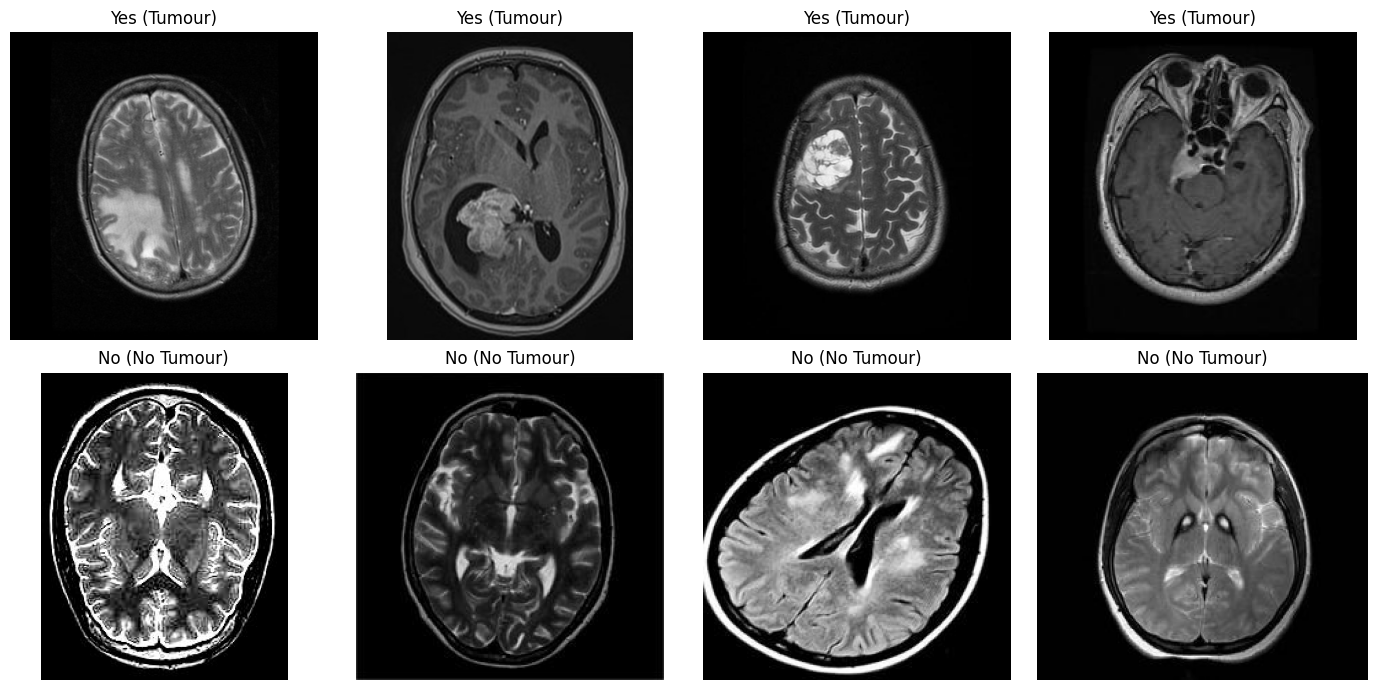

In [10]:
random_yes = random.sample(yes_files, 4)
random_no = random.sample(no_files, 4)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, img_path in enumerate(random_yes):
    img = Image.open(img_path)
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title("Yes (Tumour)")
    axes[0, i].axis("off")

for i, img_path in enumerate(random_no):
    img = Image.open(img_path)
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title("No (No Tumour)")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

*Sample Image Figure*

In [11]:
sample_fig_path = os.path.join(base_path, "figures", "sample_images.png")
fig.savefig(sample_fig_path, bbox_inches="tight")
print("Sample image figure saved at:", sample_fig_path)

Sample image figure saved at: /content/drive/MyDrive/brain_tumour_project/figures/sample_images.png


*Check image dimensions*

In [12]:
all_files = yes_files + no_files

image_sizes = []
for img_path in random.sample(all_files, min(100, len(all_files))):  # check 100 random images
    img = Image.open(img_path)
    image_sizes.append(img.size)

unique_sizes = set(image_sizes)

print("Number of unique image sizes found in sample:", len(unique_sizes))
print("Some example sizes:", list(unique_sizes)[:10])

Number of unique image sizes found in sample: 23
Some example sizes: [(630, 630), (456, 538), (286, 356), (451, 539), (470, 552), (402, 497), (232, 217), (257, 307), (512, 512), (400, 539)]


*My observation*

In [13]:
notes_path_2 = os.path.join(base_path, "report_notes", "02_image_inspection.txt")

notes_text_2 = f"""
Step 2: Image inspection

A visual inspection of sample MRI images was carried out from both classes ('yes' and 'no').
The purpose was to understand the appearance of the dataset before preprocessing and modelling.

Observations:
- The dataset contains grayscale-style MRI brain images.
- The two classes represent tumour presence ('yes') and tumour absence ('no').
- Visual differences appear to exist between the classes, although the degree of contrast and clarity may vary.
- A sample of image sizes was checked.
- Number of unique image sizes in inspected sample: {len(unique_sizes)}
- Example image sizes: {list(unique_sizes)[:10]}

Interpretation:
If image dimensions are inconsistent, resizing will be necessary before training the CNN model.
This supports a standardised preprocessing pipeline and ensures compatibility with deep learning architectures.
"""

with open(notes_path_2, "w") as f:
    f.write(notes_text_2)

print("Notes_2 saved.")

Notes_2 saved.


In a visual inspection of the MRI dataset was performed by displaying random examples from both the tumour and non-tumour classes. This helped confirm that the dataset is suitable for image classification and provided an initial understanding of image appearance, contrast, and variation. A sample of image dimensions was also checked to determine whether resizing would be required during preprocessing. This inspection supports the dataset description and justifies later preprocessing decisions.

*Import the libraries*

In [14]:
import os
import shutil
from sklearn.model_selection import train_test_split

*Create a new split-data folder*

In [15]:
split_base = os.path.join(base_path, "data_split")

folders_to_make = [
    "train/yes", "train/no",
    "val/yes", "val/no",
    "test/yes", "test/no"
]

for folder in folders_to_make:
    os.makedirs(os.path.join(split_base, folder), exist_ok=True)

print("Split folders created successfully.")

Split folders created successfully.


*Split the yes class*

In [16]:
yes_train, yes_temp = train_test_split(
    yes_files, test_size=0.30, random_state=42
)

yes_val, yes_test = train_test_split(
    yes_temp, test_size=0.50, random_state=42
)

print("YES class split:")
print("Train:", len(yes_train))
print("Validation:", len(yes_val))
print("Test:", len(yes_test))

YES class split:
Train: 1907
Validation: 409
Test: 409


*Split the no class*

In [17]:
no_train, no_temp = train_test_split(
    no_files, test_size=0.30, random_state=42
)

no_val, no_test = train_test_split(
    no_temp, test_size=0.50, random_state=42
)

print("NO class split:")
print("Train:", len(no_train))
print("Validation:", len(no_val))
print("Test:", len(no_test))

NO class split:
Train: 1907
Validation: 409
Test: 409


*Copy files into the new folders*

In [18]:
def copy_files(file_list, destination_folder):
    for file_path in file_list:
        filename = os.path.basename(file_path)
        shutil.copy(file_path, os.path.join(destination_folder, filename))

# Copy yes files
copy_files(yes_train, os.path.join(split_base, "train", "yes"))
copy_files(yes_val, os.path.join(split_base, "val", "yes"))
copy_files(yes_test, os.path.join(split_base, "test", "yes"))

# Copy no files
copy_files(no_train, os.path.join(split_base, "train", "no"))
copy_files(no_val, os.path.join(split_base, "val", "no"))
copy_files(no_test, os.path.join(split_base, "test", "no"))

print("Files copied into train/val/test folders successfully.")

Files copied into train/val/test folders successfully.


*Verify the counts*

In [47]:
for split in ["train", "val", "test"]:
    for cls in ["yes", "no"]:
        folder_path = os.path.join(split_base, split, cls)
        print(split, cls, len(os.listdir(folder_path)))

train yes 2702
train no 2709
val yes 1265
val no 1302
test yes 1283
test no 1301


*Save the split counts for my report*

In [20]:
notes_path_3 = os.path.join(base_path, "report_notes", "03_data_split.txt")

notes_text_3 = f"""
Step 3: Train/validation/test split

The original dataset was stored in a single Training directory, so a manual split was created.
A 70/15/15 split was used for training, validation, and testing.

Split counts:
Train yes: {len(yes_train)}
Train no: {len(no_train)}
Validation yes: {len(yes_val)}
Validation no: {len(no_val)}
Test yes: {len(yes_test)}
Test no: {len(no_test)}

Interpretation:
The split preserved class balance across all subsets.
This ensures that model training, validation, and final testing are performed on comparable data distributions.
The test set remains untouched during model development and will be used only for final evaluation.
"""

with open(notes_path_3, "w") as f:
    f.write(notes_text_3)

print("Notes_3 saved.")

Notes_3 saved.


In the MRI dataset was divided into training, validation, and test subsets using a 70/15/15 ratio. Since the original dataset was provided in a single folder, a manual split was necessary. The split was performed separately for the 'yes' and 'no' classes in order to preserve class balance across all subsets. This ensures that model training, tuning, and final evaluation are based on comparable data distributions and prevents leakage from the test set into the development process.

*Import TensorFlow tools*

In [21]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

*Define the folder paths*

In [22]:
train_dir = os.path.join(split_base, "train")
val_dir = os.path.join(split_base, "val")
test_dir = os.path.join(split_base, "test")

print("Train directory:", train_dir)
print("Validation directory:", val_dir)
print("Test directory:", test_dir)

Train directory: /content/drive/MyDrive/brain_tumour_project/data_split/train
Validation directory: /content/drive/MyDrive/brain_tumour_project/data_split/val
Test directory: /content/drive/MyDrive/brain_tumour_project/data_split/test


*Set the preprocessing choices*

In [23]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

*Create the data generators*

In [24]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

*Create the train, validation, and test generators*

In [25]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False
)

Found 5411 images belonging to 2 classes.
Found 2567 images belonging to 2 classes.
Found 2584 images belonging to 2 classes.


*Check the class labels*

In [26]:
print("Class indices:", train_generator.class_indices)

Class indices: {'no': 0, 'yes': 1}


*Check one batch shape*

In [27]:
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
First 10 labels: [0. 0. 1. 1. 0. 1. 1. 0. 0. 0.]


*Display some augmented training images*

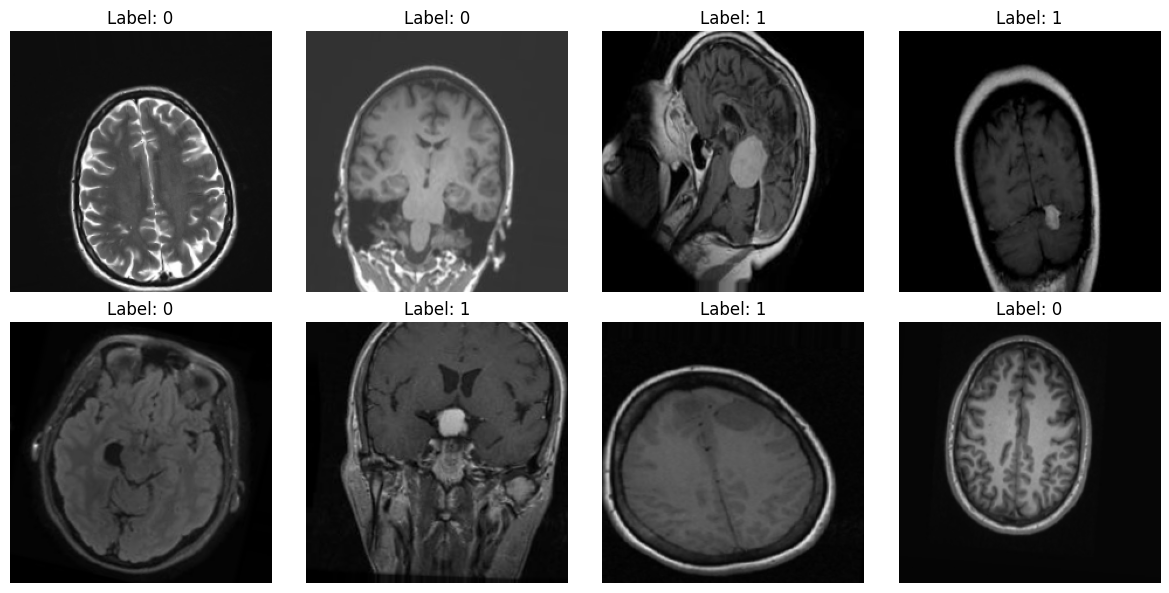

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.set_title(f"Label: {int(labels[i])}")
    ax.axis("off")

plt.tight_layout()
plt.show()

*Save the augmentation preview figure*

In [29]:
aug_fig_path = os.path.join(base_path, "figures", "augmented_preview.png")
fig.savefig(aug_fig_path, bbox_inches="tight")
print("Augmented preview figure saved at:", aug_fig_path)

Augmented preview figure saved at: /content/drive/MyDrive/brain_tumour_project/figures/augmented_preview.png


*Save my preprocessing note*

In [30]:
notes_path_4 = os.path.join(base_path, "report_notes", "04_preprocessing_setup.txt")

notes_text_4 = f"""
Step 4: Image preprocessing setup

The dataset was preprocessed using TensorFlow image generators.

Preprocessing decisions:
- Images were resized to {IMG_SIZE[0]} x {IMG_SIZE[1]} pixels.
- Pixel values were normalised using rescaling by 1/255.
- Images were loaded in RGB format to ensure compatibility with CNN and transfer learning architectures.
- Batch size was set to {BATCH_SIZE}.

Training augmentation:
- Rotation range: 15 degrees
- Width shift range: 0.10
- Height shift range: 0.10
- Zoom range: 0.10
- Horizontal flip: enabled

Validation and test data:
- Only resizing and normalisation were applied.
- No augmentation was applied to validation or test sets in order to preserve a fair evaluation setting.

Interpretation:
Preprocessing standardised the image inputs and increased the diversity of the training data.
This reduces the risk of overfitting and supports more reliable model learning.
"""

with open(notes_path_4, "w") as f:
    f.write(notes_text_4)

print("Notes_4 saved.")

Notes_4 saved.


In the MRI images were preprocessed using TensorFlow image generators. All images were resized to 224 × 224 pixels and normalised by scaling pixel intensities to the range 0–1. Data augmentation was applied only to the training set using small rotations, shifts, zoom, and horizontal flipping in order to improve generalisation and reduce overfitting. Validation and test images were not augmented, ensuring that model evaluation remained fair and unbiased.

*Import the required Keras layers*

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Precision, Recall

*Build the baseline CNN*

In [32]:
baseline_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


*Compile the model*

In [33]:
baseline_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc'), Precision(name='precision'), Recall(name='recall')]
)

*Display the model summary*

In [34]:
baseline_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 111, 111, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 54, 54, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

*The model summary to a text file*

In [35]:
summary_path = os.path.join(base_path, "results", "baseline_cnn_summary.txt")

with open(summary_path, "w") as f:
    baseline_cnn.summary(print_fn=lambda x: f.write(x + "\n"))

print("Baseline CNN summary saved at:", summary_path)

Baseline CNN summary saved at: /content/drive/MyDrive/brain_tumour_project/results/baseline_cnn_summary.txt


*My report note*

In [36]:
notes_path_5 = os.path.join(base_path, "report_notes", "05_baseline_model.txt")

notes_text_5 = f"""
Step 5: Baseline CNN model

A baseline convolutional neural network (CNN) was implemented for the binary classification of brain MRI images.

Architecture:
- Conv2D with 32 filters, 3x3 kernel, ReLU activation
- MaxPooling2D
- BatchNormalization
- Conv2D with 64 filters, 3x3 kernel, ReLU activation
- MaxPooling2D
- BatchNormalization
- Conv2D with 128 filters, 3x3 kernel, ReLU activation
- MaxPooling2D
- BatchNormalization
- Flatten
- Dense layer with 128 units, ReLU activation
- Dropout with rate 0.5
- Output Dense layer with 1 unit and sigmoid activation

Compilation settings:
- Optimiser: Adam
- Learning rate: 0.001
- Loss function: binary_crossentropy
- Metrics: accuracy, AUC, precision, recall

Justification:
This model was selected as a baseline because CNNs are appropriate for image classification tasks and can automatically learn spatial features from MRI scans.
The model is simple enough to serve as an interpretable benchmark, while still being capable of learning meaningful visual patterns.
A stronger transfer learning model will later be compared against this baseline.
"""

with open(notes_path_5, "w") as f:
    f.write(notes_text_5)

print("Notes_5 saved.")

Notes_5 saved.


In a baseline convolutional neural network was constructed for binary brain MRI classification. The model included three convolutional blocks with pooling and batch normalisation, followed by a dense classification head with dropout regularisation. It was compiled using the Adam optimiser and binary cross-entropy loss, with accuracy, AUC, precision, and recall used as training metrics. This model serves as an initial benchmark for later comparison with a transfer learning approach.

*Import callbacks*

In [37]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

*Set up callbacks*

In [38]:
baseline_model_path = os.path.join(base_path, "saved_models", "baseline_cnn_best.keras")

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    baseline_model_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

*Train the baseline CNN*

In [39]:
history_baseline = baseline_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)

Epoch 1/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5749 - auc: 0.5943 - loss: 3.6792 - precision: 0.5703 - recall: 0.6846
Epoch 1: val_loss improved from None to 1.77497, saving model to /content/drive/MyDrive/brain_tumour_project/saved_models/baseline_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumour_project/saved_models/baseline_cnn_best.keras
170/170 ━━━━━━━━━━━━━━━━━━━━ 1196s 7s/step - accuracy: 0.5607 - auc: 0.5807 - loss: 1.9559 - precision: 0.5417 - recall: 0.7813 - val_accuracy: 0.5076 - val_auc: 0.6106 - val_loss: 1.7750 - val_precision: 0.5002 - val_recall: 0.9897 - learning_rate: 0.0010
Epoch 2/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5601 - auc: 0.5842 - loss: 0.8758 - precision: 0.5378 - recall: 0.8316
Epoch 2: val_loss improved from 1.77497 to 0.69057, saving model to /content/drive/MyDrive/brain_tumour_project/saved_models/baseline_cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/br

*Save the training history*

In [40]:
import pandas as pd

history_df = pd.DataFrame(history_baseline.history)
history_path = os.path.join(base_path, "results", "baseline_training_history.csv")
history_df.to_csv(history_path, index=False)

print("Training history saved at:", history_path)

Training history saved at: /content/drive/MyDrive/brain_tumour_project/results/baseline_training_history.csv


*Plot training and validation accuracy*

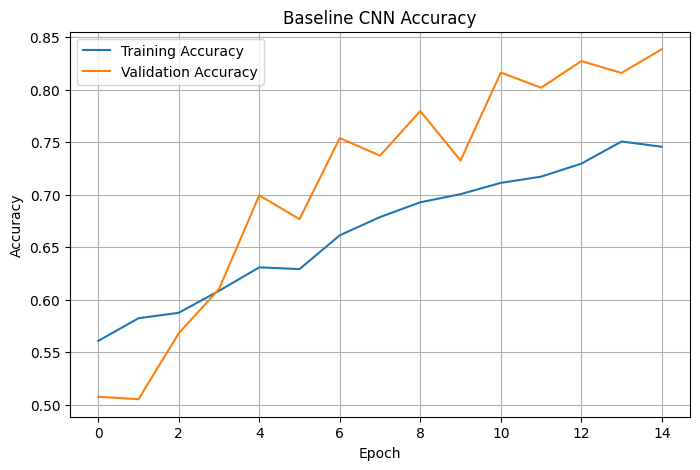

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history["accuracy"], label="Training Accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Accuracy")
plt.legend()
plt.grid(True)
plt.show()

*Plot training and validation loss*

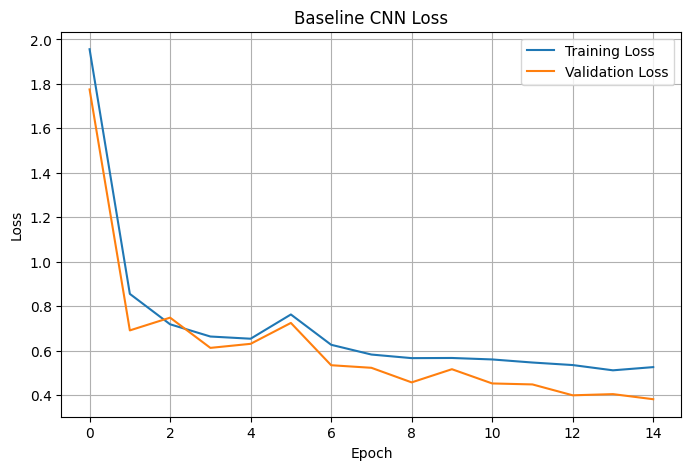

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history["loss"], label="Training Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss")
plt.legend()
plt.grid(True)
plt.show()

*The accuracy and loss figures*

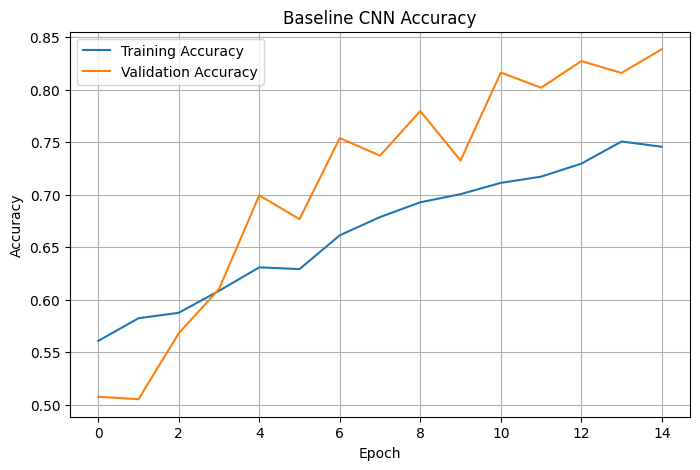

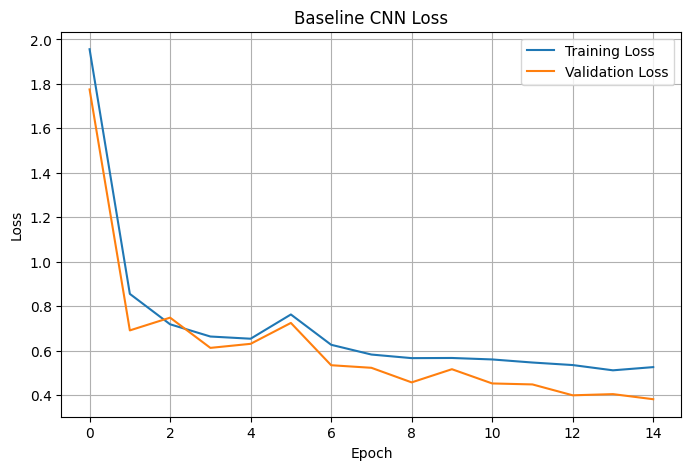

Saved accuracy curve at: /content/drive/MyDrive/brain_tumour_project/figures/baseline_accuracy_curve.png
Saved loss curve at: /content/drive/MyDrive/brain_tumour_project/figures/baseline_loss_curve.png


In [43]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history["accuracy"], label="Training Accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Accuracy")
plt.legend()
plt.grid(True)
acc_fig_path = os.path.join(base_path, "figures", "baseline_accuracy_curve.png")
plt.savefig(acc_fig_path, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history["loss"], label="Training Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss")
plt.legend()
plt.grid(True)
loss_fig_path = os.path.join(base_path, "figures", "baseline_loss_curve.png")
plt.savefig(loss_fig_path, bbox_inches="tight")
plt.show()

print("Saved accuracy curve at:", acc_fig_path)
print("Saved loss curve at:", loss_fig_path)

*The final epoch values*

In [44]:
final_epoch = len(history_baseline.history["loss"]) - 1

print("Final training accuracy:", history_baseline.history["accuracy"][final_epoch])
print("Final validation accuracy:", history_baseline.history["val_accuracy"][final_epoch])
print("Final training loss:", history_baseline.history["loss"][final_epoch])
print("Final validation loss:", history_baseline.history["val_loss"][final_epoch])

Final training accuracy: 0.7455183863639832
Final validation accuracy: 0.8383327126502991
Final training loss: 0.5253263711929321
Final validation loss: 0.3808518946170807


In [45]:
baseline_metrics_path = os.path.join(base_path, "results", "baseline_epoch_summary.txt")

with open(baseline_metrics_path, "w") as f:
    f.write(f"Final training accuracy: {history_baseline.history['accuracy'][final_epoch]}\n")
    f.write(f"Final validation accuracy: {history_baseline.history['val_accuracy'][final_epoch]}\n")
    f.write(f"Final training loss: {history_baseline.history['loss'][final_epoch]}\n")
    f.write(f"Final validation loss: {history_baseline.history['val_loss'][final_epoch]}\n")

print("Baseline epoch summary saved at:", baseline_metrics_path)

Baseline epoch summary saved at: /content/drive/MyDrive/brain_tumour_project/results/baseline_epoch_summary.txt


*Note for the report*

In [46]:
notes_path_6 = os.path.join(base_path, "report_notes", "06_baseline_training.txt")

notes_text_6 = f"""
Step 6: Baseline CNN training

The baseline CNN was trained using the training set and evaluated on the validation set.
Training was conducted for up to 15 epochs using the Adam optimiser and binary cross-entropy loss.

Callbacks used:
- EarlyStopping to stop training when validation loss stopped improving
- ModelCheckpoint to save the best-performing model
- ReduceLROnPlateau to reduce the learning rate when validation progress plateaued

Outputs saved:
- Best model file
- Training history CSV
- Accuracy curve
- Loss curve

Interpretation guide:
- If training accuracy increases while validation accuracy remains much lower, this suggests overfitting.
- If both training and validation accuracy remain low, this suggests underfitting.
- If training and validation curves improve together and stay relatively close, this suggests better generalisation.

Final recorded values:
- Final training accuracy: {history_baseline.history['accuracy'][final_epoch]}
- Final validation accuracy: {history_baseline.history['val_accuracy'][final_epoch]}
- Final training loss: {history_baseline.history['loss'][final_epoch]}
- Final validation loss: {history_baseline.history['val_loss'][final_epoch]}
"""

with open(notes_path_6, "w") as f:
    f.write(notes_text_6)

print("Notes_6 saved.")

Notes_6 saved.


In the baseline CNN was trained on the augmented training set and monitored using the validation set. Early stopping, model checkpointing, and adaptive learning-rate reduction were applied in order to improve training stability and reduce overfitting. Training and validation accuracy and loss curves were saved so that the learning behaviour of the model could be analysed and discussed in the evaluation section of the report.

*Import evaluation libraries*

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

*Load the best saved baseline model*

In [79]:
best_baseline_model = load_model(baseline_model_path)
print("Best baseline model loaded successfully.")

Best baseline model loaded successfully.


*Reset the test generator*

In [80]:
test_generator.reset()

*Predict probabilities on the test set*

In [81]:
y_prob = best_baseline_model.predict(test_generator)
y_prob = y_prob.ravel()

y_pred = (y_prob >= 0.5).astype(int)
y_true = test_generator.classes

print("Number of true labels:", len(y_true))
print("Number of predicted labels:", len(y_pred))

26/26 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step
Number of true labels: 818
Number of predicted labels: 818


*Calculate the evaluation metrics*

In [82]:
test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred)
test_recall = recall_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred)
test_auc = roc_auc_score(y_true, y_prob)

print("Test Accuracy :", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall   :", test_recall)
print("Test F1-score :", test_f1)
print("Test AUC      :", test_auc)

Test Accuracy : 0.8031784841075794
Test Precision: 0.8757575757575757
Test Recall   : 0.706601466992665
Test F1-score : 0.7821380243572396
Test AUC      : 0.8919004549231533


*Print the classification report*

In [83]:
report = classification_report(y_true, y_pred, target_names=["no", "yes"])
print(report)

              precision    recall  f1-score   support

          no       0.75      0.90      0.82       409
         yes       0.88      0.71      0.78       409

    accuracy                           0.80       818
   macro avg       0.81      0.80      0.80       818
weighted avg       0.81      0.80      0.80       818



*Save the classification report to a text file*

In [84]:
report_path = os.path.join(base_path, "results", "baseline_classification_report.txt")

with open(report_path, "w") as f:
    f.write(report)

print("Classification report saved at:", report_path)

Classification report saved at: /content/drive/MyDrive/brain_tumour_project/results/baseline_classification_report.txt


*Create the confusion matrix*

In [85]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[368  41]
 [120 289]]


*Plot the confusion matrix*

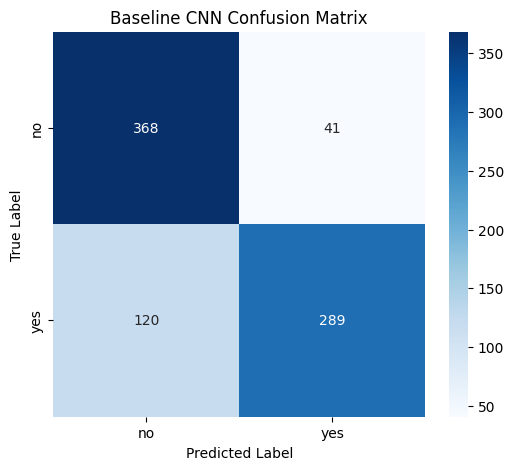

In [86]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["no", "yes"],
            yticklabels=["no", "yes"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Baseline CNN Confusion Matrix")
plt.show()

*Save the confusion matrix figure*

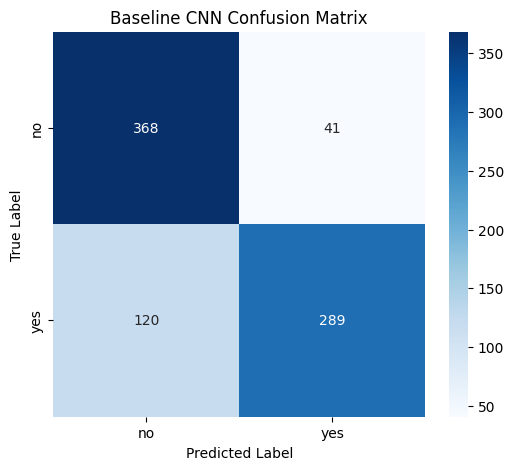

Confusion matrix saved at: /content/drive/MyDrive/brain_tumour_project/figures/baseline_confusion_matrix.png


In [87]:
cm_fig_path = os.path.join(base_path, "figures", "baseline_confusion_matrix.png")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["no", "yes"],
            yticklabels=["no", "yes"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Baseline CNN Confusion Matrix")
plt.savefig(cm_fig_path, bbox_inches="tight")
plt.show()

print("Confusion matrix saved at:", cm_fig_path)

*Plot the ROC curve*

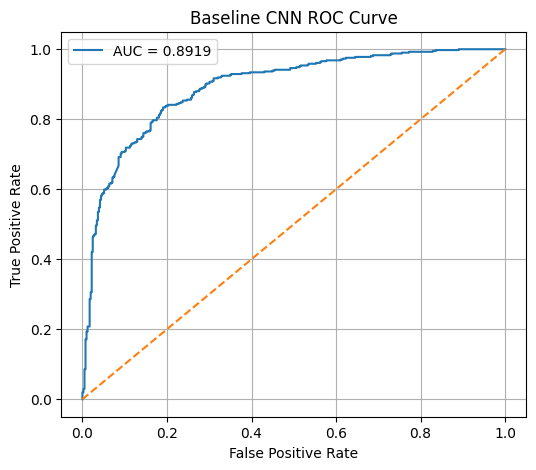

In [88]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline CNN ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

*Save the ROC curve*

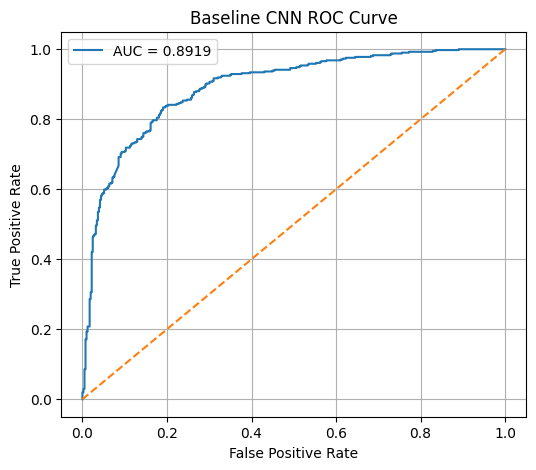

ROC curve saved at: /content/drive/MyDrive/brain_tumour_project/figures/baseline_roc_curve.png


In [89]:
roc_fig_path = os.path.join(base_path, "figures", "baseline_roc_curve.png")

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline CNN ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig(roc_fig_path, bbox_inches="tight")
plt.show()

print("ROC curve saved at:", roc_fig_path)

*Save the main test metrics*

In [90]:
metrics_path = os.path.join(base_path, "results", "baseline_test_metrics.txt")

with open(metrics_path, "w") as f:
    f.write(f"Test Accuracy: {test_accuracy:.6f}\n")
    f.write(f"Test Precision: {test_precision:.6f}\n")
    f.write(f"Test Recall: {test_recall:.6f}\n")
    f.write(f"Test F1-score: {test_f1:.6f}\n")
    f.write(f"Test AUC: {test_auc:.6f}\n")

print("Baseline test metrics saved at:", metrics_path)

Baseline test metrics saved at: /content/drive/MyDrive/brain_tumour_project/results/baseline_test_metrics.txt


*Report Note*

In [91]:
notes_path_7 = os.path.join(base_path, "report_notes", "07_baseline_evaluation.txt")

notes_text_7 = f"""
Step 7: Baseline CNN evaluation

The best saved baseline CNN model was evaluated on the untouched test set.

Test-set metrics:
- Accuracy: {test_accuracy:.6f}
- Precision: {test_precision:.6f}
- Recall: {test_recall:.6f}
- F1-score: {test_f1:.6f}
- AUC: {test_auc:.6f}

Additional outputs:
- Classification report
- Confusion matrix
- ROC curve

Interpretation guide:
- Accuracy shows overall correctness.
- Precision shows how many predicted tumour cases were actually correct.
- Recall shows how many real tumour cases were successfully detected.
- F1-score balances precision and recall.
- AUC reflects ranking performance across classification thresholds.

These results provide the baseline benchmark that will later be compared against a transfer learning model.
"""

with open(notes_path_7, "w") as f:
    f.write(notes_text_7)

print("Notes_7 saved.")

Notes_7 saved.


The best saved baseline CNN model was evaluated on the untouched test set. Performance was measured using accuracy, precision, recall, F1-score, and AUC, in line with the assignment requirements for classification tasks. A classification report, confusion matrix, and ROC curve were also generated in order to provide a more complete assessment of predictive performance and class-specific behaviour.

***Fix the test-set mismatch***

1. Recheck actual test folder counts

In [63]:
for cls in ["yes", "no"]:
    folder_path = os.path.join(split_base, "test", cls)
    print(cls, len(os.listdir(folder_path)))

yes 1283
no 1301


2. Check what the current generator is reading

In [64]:
print("test_dir:", test_dir)
print("Generator samples:", test_generator.samples)
print("Class indices:", test_generator.class_indices)

test_dir: /content/drive/MyDrive/brain_tumour_project/data_split/test
Generator samples: 2584
Class indices: {'no': 0, 'yes': 1}


3. Recreate the test generator

In [65]:
test_dir = os.path.join(split_base, "test")

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False
)

print("New test generator samples:", test_generator.samples)

Found 2584 images belonging to 2 classes.
New test generator samples: 2584


4. Reset and predict again

In [66]:
test_generator.reset()

y_prob = best_baseline_model.predict(test_generator)
y_prob = y_prob.ravel()

y_pred = (y_prob >= 0.5).astype(int)
y_true = test_generator.classes

print("Number of true labels:", len(y_true))
print("Number of predicted labels:", len(y_pred))

81/81 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step
Number of true labels: 2584
Number of predicted labels: 2584


5. Recalculate corrected metrics

In [67]:
test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred)
test_recall = recall_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred)
test_auc = roc_auc_score(y_true, y_prob)

print("Corrected Test Accuracy :", test_accuracy)
print("Corrected Test Precision:", test_precision)
print("Corrected Test Recall   :", test_recall)
print("Corrected Test F1-score :", test_f1)
print("Corrected Test AUC      :", test_auc)

Corrected Test Accuracy : 0.8239164086687306
Corrected Test Precision: 0.8854748603351955
Corrected Test Recall   : 0.7412314886983632
Corrected Test F1-score : 0.8069579974543912
Corrected Test AUC      : 0.9061322215718708


In [68]:
# 6. Recreate the classification report
report = classification_report(y_true, y_pred, target_names=["no", "yes"])
print(report)

report_path = os.path.join(base_path, "results", "baseline_classification_report.txt")
with open(report_path, "w") as f:
    f.write(report)

print("Corrected classification report saved at:", report_path)

              precision    recall  f1-score   support

          no       0.78      0.91      0.84      1301
         yes       0.89      0.74      0.81      1283

    accuracy                           0.82      2584
   macro avg       0.83      0.82      0.82      2584
weighted avg       0.83      0.82      0.82      2584

Corrected classification report saved at: /content/drive/MyDrive/brain_tumour_project/results/baseline_classification_report.txt


[[1178  123]
 [ 332  951]]


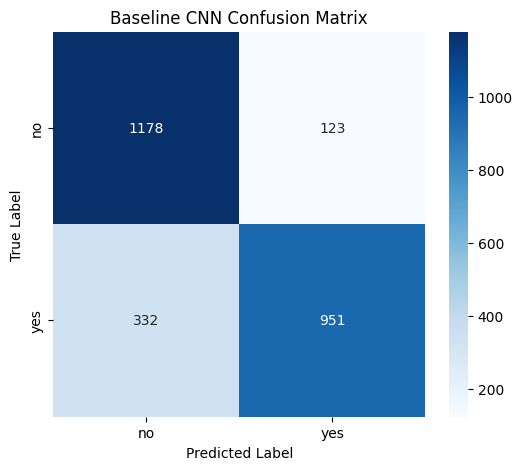

In [69]:
# 7. Recreate the confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["no", "yes"],
            yticklabels=["no", "yes"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Baseline CNN Confusion Matrix")
plt.show()

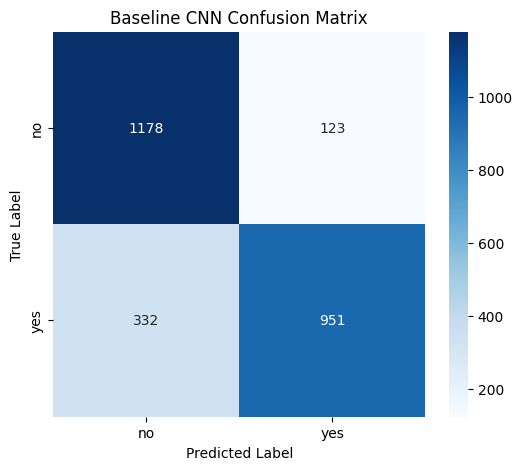

Corrected confusion matrix saved at: /content/drive/MyDrive/brain_tumour_project/figures/baseline_confusion_matrix.png


In [70]:
# 8. Save the corrected confusion matrix
cm_fig_path = os.path.join(base_path, "figures", "baseline_confusion_matrix.png")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["no", "yes"],
            yticklabels=["no", "yes"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Baseline CNN Confusion Matrix")
plt.savefig(cm_fig_path, bbox_inches="tight")
plt.show()

print("Corrected confusion matrix saved at:", cm_fig_path)

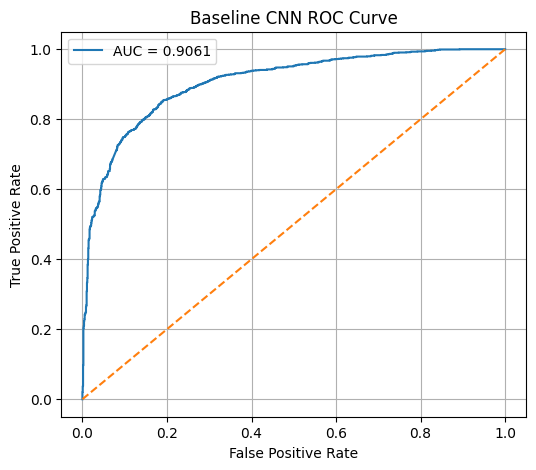

In [71]:
# 9. Recreate the ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline CNN ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

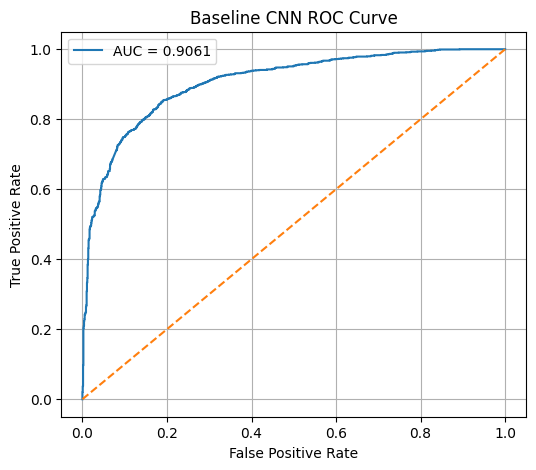

Corrected ROC curve saved at: /content/drive/MyDrive/brain_tumour_project/figures/baseline_roc_curve.png


In [72]:
# 10. Save the corrected ROC curve
roc_fig_path = os.path.join(base_path, "figures", "baseline_roc_curve.png")

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline CNN ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig(roc_fig_path, bbox_inches="tight")
plt.show()

print("Corrected ROC curve saved at:", roc_fig_path)

In [73]:
# 11. Save the corrected main test metrics
metrics_path = os.path.join(base_path, "results", "baseline_test_metrics.txt")

with open(metrics_path, "w") as f:
    f.write(f"Test Accuracy: {test_accuracy:.6f}\n")
    f.write(f"Test Precision: {test_precision:.6f}\n")
    f.write(f"Test Recall: {test_recall:.6f}\n")
    f.write(f"Test F1-score: {test_f1:.6f}\n")
    f.write(f"Test AUC: {test_auc:.6f}\n")

print("Corrected baseline test metrics saved at:", metrics_path)

Corrected baseline test metrics saved at: /content/drive/MyDrive/brain_tumour_project/results/baseline_test_metrics.txt


In [74]:
# 12. Save the corrected report note
notes_path_7 = os.path.join(base_path, "report_notes", "07_baseline_evaluation.txt")

notes_text_7 = f"""
Step 7: Baseline CNN evaluation

The best saved baseline CNN model was evaluated on the untouched test set.

Corrected test-set metrics:
- Accuracy: {test_accuracy:.6f}
- Precision: {test_precision:.6f}
- Recall: {test_recall:.6f}
- F1-score: {test_f1:.6f}
- AUC: {test_auc:.6f}

Additional outputs:
- Classification report
- Confusion matrix
- ROC curve

Interpretation:
The corrected evaluation was performed on the proper test set after recreating the test generator.
These results provide the baseline benchmark that will later be compared against a transfer learning model.
"""

with open(notes_path_7, "w") as f:
    f.write(notes_text_7)

print("Corrected notes_7 saved.")

Corrected notes_7 saved.


In [75]:
# 13. Final check
print("Final corrected test samples:", test_generator.samples)
print("Final corrected metrics:")
print("Accuracy :", test_accuracy)
print("Precision:", test_precision)
print("Recall   :", test_recall)
print("F1-score :", test_f1)
print("AUC      :", test_auc)

Final corrected test samples: 2584
Final corrected metrics:
Accuracy : 0.8239164086687306
Precision: 0.8854748603351955
Recall   : 0.7412314886983632
F1-score : 0.8069579974543912
AUC      : 0.9061322215718708


**Fully reset and rebuild the split folders**

In [76]:
# =========================================================
# Step 7.6 — FULL RESET OF data_split
# This will delete the current split folder and rebuild it cleanly
# =========================================================

import os
import shutil
from sklearn.model_selection import train_test_split

# 1. Remove the old split folder completely
split_base = os.path.join(base_path, "data_split")

if os.path.exists(split_base):
    shutil.rmtree(split_base)
    print("Old data_split folder deleted.")
else:
    print("No existing data_split folder found.")

# 2. Recreate fresh split folders
folders_to_make = [
    "train/yes", "train/no",
    "val/yes", "val/no",
    "test/yes", "test/no"
]

for folder in folders_to_make:
    os.makedirs(os.path.join(split_base, folder), exist_ok=True)

print("Fresh split folders created.")

# 3. Rebuild file lists from the ORIGINAL dataset
dataset_root = os.path.join(base_path, "data", "Brain (y-n)", "Training")
yes_path = os.path.join(dataset_root, "yes")
no_path = os.path.join(dataset_root, "no")

yes_files = [os.path.join(yes_path, f) for f in sorted(os.listdir(yes_path))]
no_files = [os.path.join(no_path, f) for f in sorted(os.listdir(no_path))]

print("Original yes files:", len(yes_files))
print("Original no files :", len(no_files))

# 4. Create the 70/15/15 split again
yes_train, yes_temp = train_test_split(yes_files, test_size=0.30, random_state=42)
yes_val, yes_test = train_test_split(yes_temp, test_size=0.50, random_state=42)

no_train, no_temp = train_test_split(no_files, test_size=0.30, random_state=42)
no_val, no_test = train_test_split(no_temp, test_size=0.50, random_state=42)

print("\nYES split:")
print("Train:", len(yes_train), " Val:", len(yes_val), " Test:", len(yes_test))

print("\nNO split:")
print("Train:", len(no_train), " Val:", len(no_val), " Test:", len(no_test))

# 5. Copy files into the fresh folders
def copy_files(file_list, destination_folder):
    for file_path in file_list:
        filename = os.path.basename(file_path)
        shutil.copy2(file_path, os.path.join(destination_folder, filename))

copy_files(yes_train, os.path.join(split_base, "train", "yes"))
copy_files(yes_val, os.path.join(split_base, "val", "yes"))
copy_files(yes_test, os.path.join(split_base, "test", "yes"))

copy_files(no_train, os.path.join(split_base, "train", "no"))
copy_files(no_val, os.path.join(split_base, "val", "no"))
copy_files(no_test, os.path.join(split_base, "test", "no"))

print("\nFiles copied into fresh split folders.")

# 6. Verify final counts
print("\nFinal verified split counts:")
for split in ["train", "val", "test"]:
    for cls in ["yes", "no"]:
        folder_path = os.path.join(split_base, split, cls)
        print(split, cls, len(os.listdir(folder_path)))

Old data_split folder deleted.
Fresh split folders created.
Original yes files: 2725
Original no files : 2725

YES split:
Train: 1907  Val: 409  Test: 409

NO split:
Train: 1907  Val: 409  Test: 409

Files copied into fresh split folders.

Final verified split counts:
train yes 1907
train no 1907
val yes 409
val no 409
test yes 409
test no 409


**Recreate all generators from the clean split**

In [77]:
# =========================================================
# Recreate generators from the CLEAN split
# =========================================================

train_dir = os.path.join(split_base, "train")
val_dir = os.path.join(split_base, "val")
test_dir = os.path.join(split_base, "test")

print("Train directory:", train_dir)
print("Validation directory:", val_dir)
print("Test directory:", test_dir)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False
)

print("\nGenerator sample counts:")
print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Train directory: /content/drive/MyDrive/brain_tumour_project/data_split/train
Validation directory: /content/drive/MyDrive/brain_tumour_project/data_split/val
Test directory: /content/drive/MyDrive/brain_tumour_project/data_split/test
Found 3814 images belonging to 2 classes.
Found 818 images belonging to 2 classes.
Found 818 images belonging to 2 classes.

Generator sample counts:
Train samples: 3814
Validation samples: 818
Test samples: 818


**Check that the test generator is finally correct or not**

In [78]:
# =========================================================
# Final check: test generator MUST be 818
# =========================================================

print("Class indices:", test_generator.class_indices)
print("Final corrected test samples:", test_generator.samples)

Class indices: {'no': 0, 'yes': 1}
Final corrected test samples: 818


In [92]:
# =========================================================
# Build the stronger transfer learning model
# =========================================================

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Precision, Recall

In [93]:
# 1. Load the pretrained MobileNetV2 base
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the convolutional base first
base_model.trainable = False

print("Base model loaded.")
print("Base model trainable:", base_model.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model loaded.
Base model trainable: False


In [94]:
# 2. Build the transfer learning model on top of MobileNetV2
inputs = Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(1, activation="sigmoid")(x)

mobilenet_model = Model(inputs, outputs)

In [95]:
# 3. Compile the model
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", AUC(name="auc"), Precision(name="precision"), Recall(name="recall")]
)

print("MobileNetV2 transfer learning model compiled successfully.")

MobileNetV2 transfer learning model compiled successfully.


In [96]:
# 4. Display the summary
mobilenet_model.summary()

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [97]:
# 5. Save the summary to a text file
mobilenet_summary_path = os.path.join(base_path, "results", "mobilenet_model_summary.txt")

with open(mobilenet_summary_path, "w") as f:
    mobilenet_model.summary(print_fn=lambda x: f.write(x + "\n"))

print("MobileNetV2 summary saved at:", mobilenet_summary_path)

MobileNetV2 summary saved at: /content/drive/MyDrive/brain_tumour_project/results/mobilenet_model_summary.txt


In [98]:
# 6. Save the report note
notes_path_8 = os.path.join(base_path, "report_notes", "08_transfer_learning_model.txt")

notes_text_8 = f"""
Step 8: Transfer learning model using MobileNetV2

A stronger image classification model was implemented using transfer learning with MobileNetV2.

Model design:
- Pretrained MobileNetV2 convolutional base with ImageNet weights
- include_top=False so that a custom classification head could be added
- Base model frozen initially to preserve pretrained feature representations
- GlobalAveragePooling2D
- BatchNormalization
- Dense layer with 128 units and ReLU activation
- Dropout with rate 0.4
- Output Dense layer with 1 unit and sigmoid activation

Compilation settings:
- Optimiser: Adam
- Learning rate: 0.001
- Loss function: binary_crossentropy
- Metrics: accuracy, AUC, precision, recall

Justification:
Transfer learning was selected because pretrained convolutional models can extract richer and more generalisable visual features than a simple CNN trained from scratch.
This is especially useful for medical image classification when dataset size is moderate rather than extremely large.
MobileNetV2 was chosen because it is computationally efficient and performs well on image tasks while remaining suitable for Google Colab training.
The model will later be compared against the baseline CNN to determine whether transfer learning improves tumour detection performance.
"""

with open(notes_path_8, "w") as f:
    f.write(notes_text_8)

print("Notes_8 saved.")

Notes_8 saved.


In a stronger transfer learning model was built using MobileNetV2 pretrained on ImageNet. The convolutional base was initially frozen so that the model could benefit from pretrained visual feature extraction while learning a task-specific classification head for binary brain MRI classification. This approach was selected because transfer learning is often more effective than training a shallow CNN from scratch when working with moderately sized medical imaging datasets.

In [100]:
# =========================================================
# Train the MobileNetV2 model
# =========================================================

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import pandas as pd
import matplotlib.pyplot as plt

In [101]:
# 1. Set up callbacks for MobileNetV2
mobilenet_model_path = os.path.join(base_path, "saved_models", "mobilenet_best.keras")

early_stopping_mobilenet = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint_mobilenet = ModelCheckpoint(
    mobilenet_model_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr_mobilenet = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

print("MobileNetV2 callbacks ready.")

MobileNetV2 callbacks ready.


In [102]:
# 2. Train the model
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stopping_mobilenet, model_checkpoint_mobilenet, reduce_lr_mobilenet]
)

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7873 - auc: 0.8643 - loss: 0.4757 - precision: 0.7886 - recall: 0.7818
Epoch 1: val_loss improved from None to 0.25743, saving model to /content/drive/MyDrive/brain_tumour_project/saved_models/mobilenet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumour_project/saved_models/mobilenet_best.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.8464 - auc: 0.9232 - loss: 0.3671 - precision: 0.8526 - recall: 0.8374 - val_accuracy: 0.8998 - val_auc: 0.9680 - val_loss: 0.2574 - val_precision: 0.8625 - val_recall: 0.9511 - learning_rate: 0.0010
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9015 - auc: 0.9651 - loss: 0.2401 - precision: 0.9074 - recall: 0.8974
Epoch 2: val_loss improved from 0.25743 to 0.18805, saving model to /content/drive/MyDrive/brain_tumour_project/saved_models/mobilenet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/brain_tumour

In [103]:
# 3. Save training history
mobilenet_history_df = pd.DataFrame(history_mobilenet.history)
mobilenet_history_path = os.path.join(base_path, "results", "mobilenet_training_history.csv")
mobilenet_history_df.to_csv(mobilenet_history_path, index=False)

print("MobileNetV2 training history saved at:", mobilenet_history_path)

MobileNetV2 training history saved at: /content/drive/MyDrive/brain_tumour_project/results/mobilenet_training_history.csv


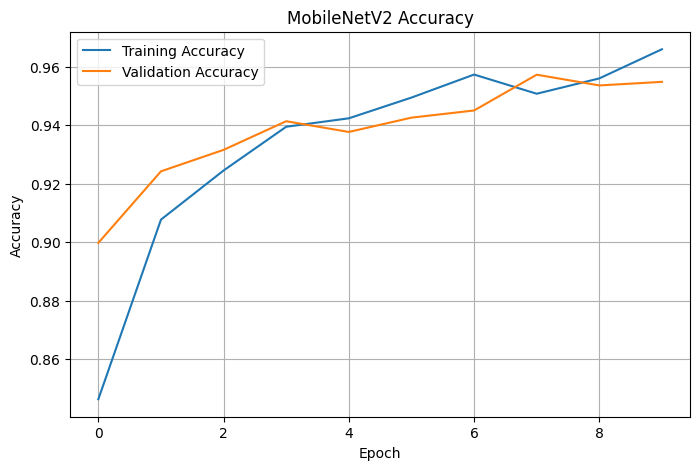

In [104]:
# 4. Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_mobilenet.history["accuracy"], label="Training Accuracy")
plt.plot(history_mobilenet.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Accuracy")
plt.legend()
plt.grid(True)
plt.show()

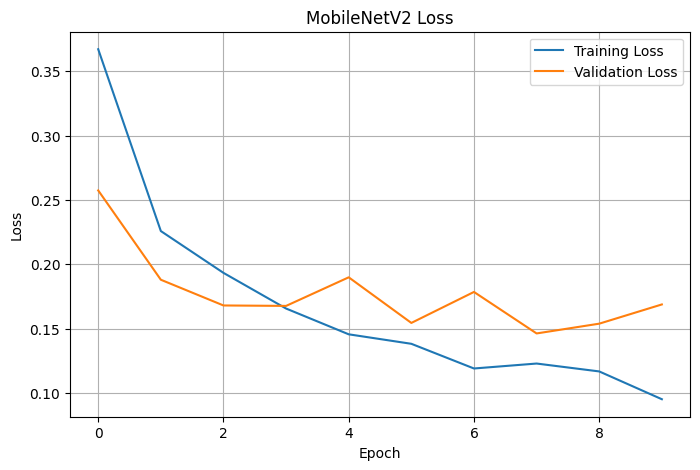

In [105]:
# 5. Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_mobilenet.history["loss"], label="Training Loss")
plt.plot(history_mobilenet.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Loss")
plt.legend()
plt.grid(True)
plt.show()

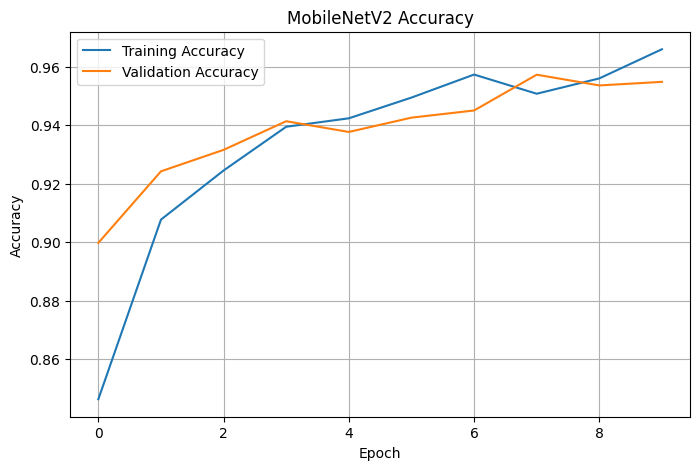

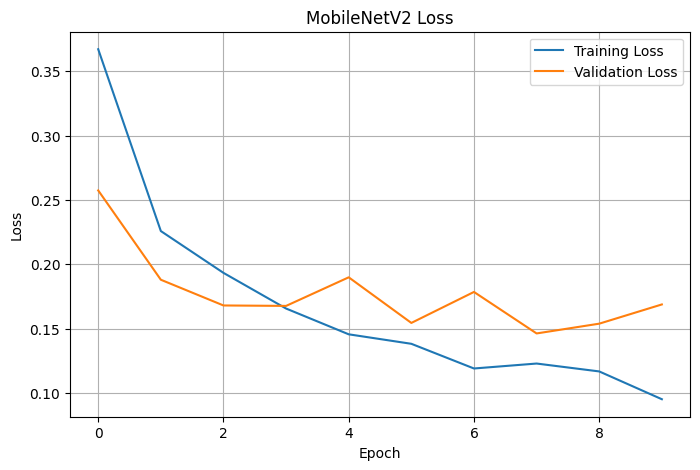

Saved MobileNetV2 accuracy curve at: /content/drive/MyDrive/brain_tumour_project/figures/mobilenet_accuracy_curve.png
Saved MobileNetV2 loss curve at: /content/drive/MyDrive/brain_tumour_project/figures/mobilenet_loss_curve.png


In [106]:
# 6. Save the accuracy and loss figures
plt.figure(figsize=(8, 5))
plt.plot(history_mobilenet.history["accuracy"], label="Training Accuracy")
plt.plot(history_mobilenet.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Accuracy")
plt.legend()
plt.grid(True)
mobilenet_acc_fig_path = os.path.join(base_path, "figures", "mobilenet_accuracy_curve.png")
plt.savefig(mobilenet_acc_fig_path, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_mobilenet.history["loss"], label="Training Loss")
plt.plot(history_mobilenet.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Loss")
plt.legend()
plt.grid(True)
mobilenet_loss_fig_path = os.path.join(base_path, "figures", "mobilenet_loss_curve.png")
plt.savefig(mobilenet_loss_fig_path, bbox_inches="tight")
plt.show()

print("Saved MobileNetV2 accuracy curve at:", mobilenet_acc_fig_path)
print("Saved MobileNetV2 loss curve at:", mobilenet_loss_fig_path)

In [107]:
# 7. Save final epoch values
final_epoch_mobilenet = len(history_mobilenet.history["loss"]) - 1

print("Final MobileNetV2 training accuracy:", history_mobilenet.history["accuracy"][final_epoch_mobilenet])
print("Final MobileNetV2 validation accuracy:", history_mobilenet.history["val_accuracy"][final_epoch_mobilenet])
print("Final MobileNetV2 training loss:", history_mobilenet.history["loss"][final_epoch_mobilenet])
print("Final MobileNetV2 validation loss:", history_mobilenet.history["val_loss"][final_epoch_mobilenet])

Final MobileNetV2 training accuracy: 0.9659150242805481
Final MobileNetV2 validation accuracy: 0.9547677040100098
Final MobileNetV2 training loss: 0.09524336457252502
Final MobileNetV2 validation loss: 0.1688573956489563


In [108]:
# 8. Save epoch summary
mobilenet_epoch_summary_path = os.path.join(base_path, "results", "mobilenet_epoch_summary.txt")

with open(mobilenet_epoch_summary_path, "w") as f:
    f.write(f"Final training accuracy: {history_mobilenet.history['accuracy'][final_epoch_mobilenet]}\n")
    f.write(f"Final validation accuracy: {history_mobilenet.history['val_accuracy'][final_epoch_mobilenet]}\n")
    f.write(f"Final training loss: {history_mobilenet.history['loss'][final_epoch_mobilenet]}\n")
    f.write(f"Final validation loss: {history_mobilenet.history['val_loss'][final_epoch_mobilenet]}\n")

print("MobileNetV2 epoch summary saved at:", mobilenet_epoch_summary_path)

MobileNetV2 epoch summary saved at: /content/drive/MyDrive/brain_tumour_project/results/mobilenet_epoch_summary.txt


In [109]:
# 9. Save the report note
notes_path_9 = os.path.join(base_path, "report_notes", "09_mobilenet_training.txt")

notes_text_9 = f"""
Step 9: MobileNetV2 training

The transfer learning model based on MobileNetV2 was trained using the training set and monitored using the validation set.
The pretrained convolutional base remained frozen during this stage, allowing the custom classification head to learn task-specific patterns.

Callbacks used:
- EarlyStopping to stop training when validation loss stopped improving
- ModelCheckpoint to save the best-performing MobileNetV2 model
- ReduceLROnPlateau to reduce the learning rate when validation progress plateaued

Outputs saved:
- Best MobileNetV2 model file
- Training history CSV
- Accuracy curve
- Loss curve

Final recorded values:
- Final training accuracy: {history_mobilenet.history['accuracy'][final_epoch_mobilenet]}
- Final validation accuracy: {history_mobilenet.history['val_accuracy'][final_epoch_mobilenet]}
- Final training loss: {history_mobilenet.history['loss'][final_epoch_mobilenet]}
- Final validation loss: {history_mobilenet.history['val_loss'][final_epoch_mobilenet]}

Interpretation guide:
- If validation accuracy improves beyond the baseline CNN, this suggests that transfer learning is extracting stronger image features.
- If validation loss is lower than the baseline CNN, this suggests better generalisation.
- If validation performance plateaus early, fine-tuning of upper convolutional layers may later be considered.
"""

with open(notes_path_9, "w") as f:
    f.write(notes_text_9)

print("Notes_9 saved.")

Notes_9 saved.


In the MobileNetV2 transfer learning model was trained using the augmented training set and monitored on the validation set. The pretrained convolutional base remained frozen during this stage so that the custom classifier could learn the dataset-specific decision boundary without immediately modifying pretrained feature representations. Learning curves were saved in order to compare training dynamics with the baseline CNN and to assess whether transfer learning improved validation performance.

In [110]:
# =========================================================
# Evaluate MobileNetV2 on the corrected test set
# and compare it with the baseline CNN
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [111]:
# 1. Preserve the baseline metrics before evaluating MobileNetV2
baseline_accuracy = test_accuracy
baseline_precision = test_precision
baseline_recall = test_recall
baseline_f1 = test_f1
baseline_auc = test_auc

print("Baseline metrics preserved for comparison.")

Baseline metrics preserved for comparison.


In [112]:
# 2. Load the best saved MobileNetV2 model
best_mobilenet_model = load_model(mobilenet_model_path)
print("Best MobileNetV2 model loaded successfully.")

Best MobileNetV2 model loaded successfully.


In [113]:
# 3. Reset the corrected test generator
test_generator.reset()
print("Corrected test generator reset.")
print("Test samples:", test_generator.samples)

Corrected test generator reset.
Test samples: 818


In [114]:
# 4. Predict probabilities on the corrected test set
mnet_y_prob = best_mobilenet_model.predict(test_generator)
mnet_y_prob = mnet_y_prob.ravel()

mnet_y_pred = (mnet_y_prob >= 0.5).astype(int)
mnet_y_true = test_generator.classes

print("Number of true labels:", len(mnet_y_true))
print("Number of predicted labels:", len(mnet_y_pred))

26/26 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step
Number of true labels: 818
Number of predicted labels: 818


In [115]:
# 5. Calculate MobileNetV2 test metrics
mnet_accuracy = accuracy_score(mnet_y_true, mnet_y_pred)
mnet_precision = precision_score(mnet_y_true, mnet_y_pred)
mnet_recall = recall_score(mnet_y_true, mnet_y_pred)
mnet_f1 = f1_score(mnet_y_true, mnet_y_pred)
mnet_auc = roc_auc_score(mnet_y_true, mnet_y_prob)

print("MobileNetV2 Test Accuracy :", mnet_accuracy)
print("MobileNetV2 Test Precision:", mnet_precision)
print("MobileNetV2 Test Recall   :", mnet_recall)
print("MobileNetV2 Test F1-score :", mnet_f1)
print("MobileNetV2 Test AUC      :", mnet_auc)

MobileNetV2 Test Accuracy : 0.9364303178484108
MobileNetV2 Test Precision: 0.9219858156028369
MobileNetV2 Test Recall   : 0.9535452322738386
MobileNetV2 Test F1-score : 0.9375
MobileNetV2 Test AUC      : 0.9857604868454876


In [116]:
# 6. Print and save the MobileNetV2 classification report
mnet_report = classification_report(mnet_y_true, mnet_y_pred, target_names=["no", "yes"])
print(mnet_report)

mnet_report_path = os.path.join(base_path, "results", "mobilenet_classification_report.txt")
with open(mnet_report_path, "w") as f:
    f.write(mnet_report)

print("MobileNetV2 classification report saved at:", mnet_report_path)

              precision    recall  f1-score   support

          no       0.95      0.92      0.94       409
         yes       0.92      0.95      0.94       409

    accuracy                           0.94       818
   macro avg       0.94      0.94      0.94       818
weighted avg       0.94      0.94      0.94       818

MobileNetV2 classification report saved at: /content/drive/MyDrive/brain_tumour_project/results/mobilenet_classification_report.txt


[[376  33]
 [ 19 390]]


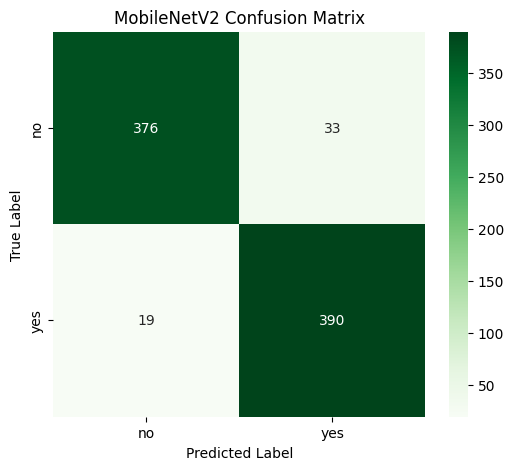

In [117]:
# 7. Create, plot, and save the MobileNetV2 confusion matrix
mnet_cm = confusion_matrix(mnet_y_true, mnet_y_pred)
print(mnet_cm)

plt.figure(figsize=(6, 5))
sns.heatmap(mnet_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["no", "yes"],
            yticklabels=["no", "yes"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

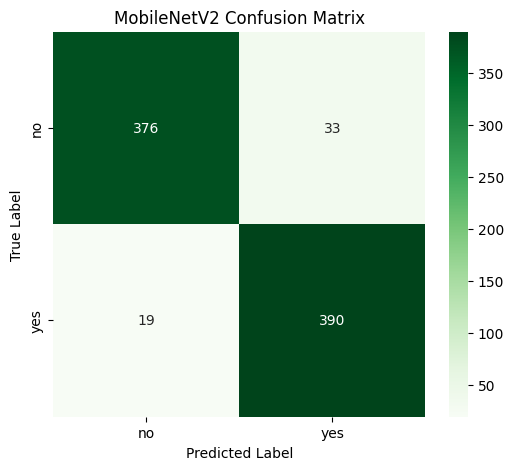

MobileNetV2 confusion matrix saved at: /content/drive/MyDrive/brain_tumour_project/figures/mobilenet_confusion_matrix.png


In [118]:
mnet_cm_fig_path = os.path.join(base_path, "figures", "mobilenet_confusion_matrix.png")

plt.figure(figsize=(6, 5))
sns.heatmap(mnet_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["no", "yes"],
            yticklabels=["no", "yes"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 Confusion Matrix")
plt.savefig(mnet_cm_fig_path, bbox_inches="tight")
plt.show()

print("MobileNetV2 confusion matrix saved at:", mnet_cm_fig_path)

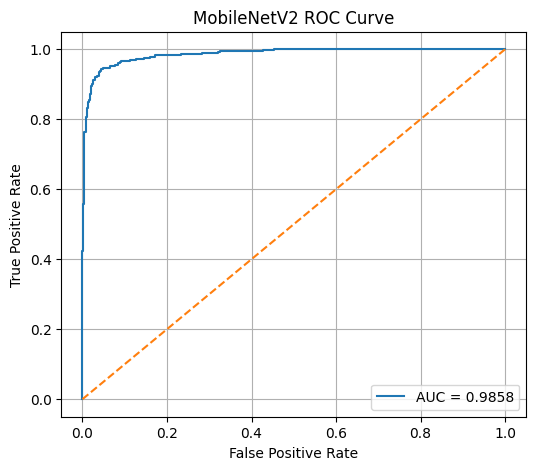

In [119]:
# 8. Plot and save the MobileNetV2 ROC curve
mnet_fpr, mnet_tpr, mnet_thresholds = roc_curve(mnet_y_true, mnet_y_prob)

plt.figure(figsize=(6, 5))
plt.plot(mnet_fpr, mnet_tpr, label=f"AUC = {mnet_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MobileNetV2 ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

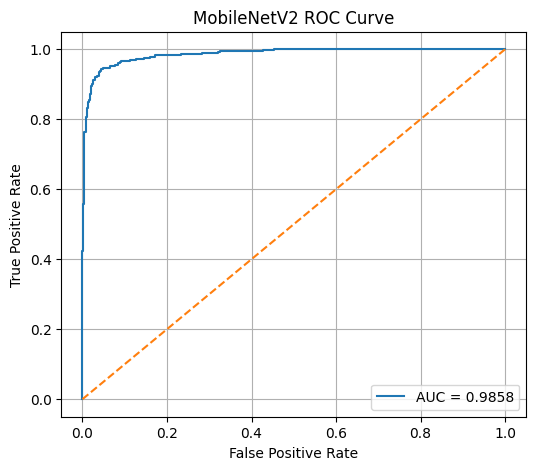

MobileNetV2 ROC curve saved at: /content/drive/MyDrive/brain_tumour_project/figures/mobilenet_roc_curve.png


In [120]:
mnet_roc_fig_path = os.path.join(base_path, "figures", "mobilenet_roc_curve.png")

plt.figure(figsize=(6, 5))
plt.plot(mnet_fpr, mnet_tpr, label=f"AUC = {mnet_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MobileNetV2 ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig(mnet_roc_fig_path, bbox_inches="tight")
plt.show()

print("MobileNetV2 ROC curve saved at:", mnet_roc_fig_path)

In [121]:
# 9. Save MobileNetV2 main test metrics
mnet_metrics_path = os.path.join(base_path, "results", "mobilenet_test_metrics.txt")

with open(mnet_metrics_path, "w") as f:
    f.write(f"Test Accuracy: {mnet_accuracy:.6f}\n")
    f.write(f"Test Precision: {mnet_precision:.6f}\n")
    f.write(f"Test Recall: {mnet_recall:.6f}\n")
    f.write(f"Test F1-score: {mnet_f1:.6f}\n")
    f.write(f"Test AUC: {mnet_auc:.6f}\n")

print("MobileNetV2 test metrics saved at:", mnet_metrics_path)

MobileNetV2 test metrics saved at: /content/drive/MyDrive/brain_tumour_project/results/mobilenet_test_metrics.txt


In [122]:
# 10. Create a direct comparison table: Baseline CNN vs MobileNetV2
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC"],
    "Baseline CNN": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_auc
    ],
    "MobileNetV2": [
        mnet_accuracy,
        mnet_precision,
        mnet_recall,
        mnet_f1,
        mnet_auc
    ]
})

comparison_df["Improvement"] = comparison_df["MobileNetV2"] - comparison_df["Baseline CNN"]
print(comparison_df)

      Metric  Baseline CNN  MobileNetV2  Improvement
0   Accuracy      0.803178     0.936430     0.133252
1  Precision      0.875758     0.921986     0.046228
2     Recall      0.706601     0.953545     0.246944
3   F1-score      0.782138     0.937500     0.155362
4        AUC      0.891900     0.985760     0.093860


In [123]:
comparison_path = os.path.join(base_path, "results", "model_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)

print("Model comparison table saved at:", comparison_path)

Model comparison table saved at: /content/drive/MyDrive/brain_tumour_project/results/model_comparison.csv


In [124]:
# 11. Save the report note
notes_path_10 = os.path.join(base_path, "report_notes", "10_mobilenet_evaluation.txt")

notes_text_10 = f"""
Step 10: MobileNetV2 evaluation and comparison

The best saved MobileNetV2 model was evaluated on the corrected untouched test set.

MobileNetV2 test-set metrics:
- Accuracy: {mnet_accuracy:.6f}
- Precision: {mnet_precision:.6f}
- Recall: {mnet_recall:.6f}
- F1-score: {mnet_f1:.6f}
- AUC: {mnet_auc:.6f}

Baseline CNN corrected test-set metrics:
- Accuracy: {baseline_accuracy:.6f}
- Precision: {baseline_precision:.6f}
- Recall: {baseline_recall:.6f}
- F1-score: {baseline_f1:.6f}
- AUC: {baseline_auc:.6f}

Comparison:
- Accuracy improvement: {mnet_accuracy - baseline_accuracy:.6f}
- Precision improvement: {mnet_precision - baseline_precision:.6f}
- Recall improvement: {mnet_recall - baseline_recall:.6f}
- F1-score improvement: {mnet_f1 - baseline_f1:.6f}
- AUC improvement: {mnet_auc - baseline_auc:.6f}

Interpretation guide:
If MobileNetV2 outperforms the baseline CNN on most or all metrics, this provides strong evidence that transfer learning is a more effective approach for this MRI classification task.
Particular attention should be given to recall for the tumour class, because improved sensitivity means fewer tumour cases are missed.
"""

with open(notes_path_10, "w") as f:
    f.write(notes_text_10)

print("Notes_10 saved.")

Notes_10 saved.


In [125]:
# 12. Final quick comparison printout
print("=== Corrected Baseline CNN ===")
print("Accuracy :", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall   :", baseline_recall)
print("F1-score :", baseline_f1)
print("AUC      :", baseline_auc)

print("\n=== MobileNetV2 ===")
print("Accuracy :", mnet_accuracy)
print("Precision:", mnet_precision)
print("Recall   :", mnet_recall)
print("F1-score :", mnet_f1)
print("AUC      :", mnet_auc)

=== Corrected Baseline CNN ===
Accuracy : 0.8031784841075794
Precision: 0.8757575757575757
Recall   : 0.706601466992665
F1-score : 0.7821380243572396
AUC      : 0.8919004549231533

=== MobileNetV2 ===
Accuracy : 0.9364303178484108
Precision: 0.9219858156028369
Recall   : 0.9535452322738386
F1-score : 0.9375
AUC      : 0.9857604868454876


The best saved MobileNetV2 model was evaluated on the corrected untouched test set using accuracy, precision, recall, F1-score, and AUC. A classification report, confusion matrix, and ROC curve were generated to provide a detailed assessment of model performance. The results were then compared directly with the corrected baseline CNN metrics in order to determine whether transfer learning improved MRI tumour classification.

In [126]:
# =========================================================
# Grad-CAM explainability for MobileNetV2
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

In [127]:
# 1. Confirm the final model and last activation layer
print("Top-level model layers:")
for layer in best_mobilenet_model.layers:
    print(layer.name)

base_mobilenet = best_mobilenet_model.get_layer("mobilenetv2_1.00_224")

print("\nLast 15 layers inside MobileNetV2 base:")
for layer in base_mobilenet.layers[-15:]:
    print(layer.name)

Top-level model layers:
input_layer_2
mobilenetv2_1.00_224
global_average_pooling2d
batch_normalization_3
dense_2
dropout_1
dense_3

Last 15 layers inside MobileNetV2 base:
block_15_depthwise_relu
block_15_project
block_15_project_BN
block_15_add
block_16_expand
block_16_expand_BN
block_16_expand_relu
block_16_depthwise
block_16_depthwise_BN
block_16_depthwise_relu
block_16_project
block_16_project_BN
Conv_1
Conv_1_bn
out_relu


In [128]:
# 2. Set the Grad-CAM target layer
# 'out_relu' works well for MobileNetV2 because it is the last activation map
LAST_CONV_LAYER_NAME = "out_relu"
print("Using Grad-CAM target layer:", LAST_CONV_LAYER_NAME)

Using Grad-CAM target layer: out_relu


In [129]:
# 3. Build file paths for the corrected test set
test_filepaths = [os.path.join(test_dir, fname) for fname in test_generator.filenames]
test_labels = test_generator.classes

print("Number of corrected test filepaths:", len(test_filepaths))
print("Number of corrected test labels:", len(test_labels))

Number of corrected test filepaths: 818
Number of corrected test labels: 818


In [130]:
# 4. Helper: load and preprocess one image for MobileNetV2
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    img = load_img(img_path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

In [149]:
def make_gradcam_heatmap(img_array, model, base_model_name="mobilenetv2_1.00_224", last_conv_layer_name="out_relu"):
    # 1. Access the nested base model and the target conv layer
    base_model = model.get_layer(base_model_name)
    target_layer = base_model.get_layer(last_conv_layer_name)

    # 2. Build a sub-model that outputs the last conv layer's activations
    conv_model = tf.keras.Model(base_model.input, target_layer.output)

    # 3. Build the 'top' part of the model to compute prediction from the conv output
    # We need to manually apply the layers that follow the base model
    # In your model: GlobalAveragePooling2D -> BatchNormalization -> Dense(128) -> Dropout -> Dense(1)
    classifier_input = tf.keras.Input(shape=target_layer.output.shape[1:])
    x = model.get_layer("global_average_pooling2d")(classifier_input)
    x = model.get_layer("batch_normalization_3")(x)
    x = model.get_layer("dense_2")(x)
    x = model.get_layer("dropout_1")(x)
    classifier_output = model.get_layer("dense_3")(x)
    classifier_model = tf.keras.Model(classifier_input, classifier_output)

    # 4. Use GradientTape to compute the gradients
    with tf.GradientTape() as tape:
        # Get the convolutional feature maps
        conv_output = conv_model(img_array)
        tape.watch(conv_output)

        # Compute the final prediction using the classifier model
        preds = classifier_model(conv_output)
        loss = preds[:, 0]

    # 5. Extract gradients of the loss with respect to the conv layer output
    grads = tape.gradient(loss, conv_output)

    # 6. Global average pooling of the gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 7. Weight the channels of the feature map
    conv_output_val = conv_output[0]
    heatmap = conv_output_val @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 8. Apply ReLU and normalize to [0, 1]
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

In [132]:
# 6. Helper: overlay heatmap on original image
def overlay_gradcam(img_path, heatmap, alpha=0.4, target_size=(224, 224)):
    img = load_img(img_path, target_size=target_size)
    img = img_to_array(img)

    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img / 255.0, 0, 1)

    return img.astype("uint8"), heatmap, superimposed_img

In [133]:
# 7. Find example indices from Step 10 results
# mnet_y_true and mnet_y_pred were already created in Step 10

correct_yes_idx = [i for i in range(len(mnet_y_true)) if mnet_y_true[i] == 1 and mnet_y_pred[i] == 1]
correct_no_idx  = [i for i in range(len(mnet_y_true)) if mnet_y_true[i] == 0 and mnet_y_pred[i] == 0]
wrong_yes_idx   = [i for i in range(len(mnet_y_true)) if mnet_y_true[i] == 1 and mnet_y_pred[i] == 0]
wrong_no_idx    = [i for i in range(len(mnet_y_true)) if mnet_y_true[i] == 0 and mnet_y_pred[i] == 1]

print("Correct tumour cases:", len(correct_yes_idx))
print("Correct non-tumour cases:", len(correct_no_idx))
print("Missed tumour cases (false negatives):", len(wrong_yes_idx))
print("False positives:", len(wrong_no_idx))

Correct tumour cases: 390
Correct non-tumour cases: 376
Missed tumour cases (false negatives): 19
False positives: 33


In [134]:
# 8. Choose examples to visualise
# Two correct tumour, two correct non-tumour, one misclassified tumour if available

selected_indices = []

selected_indices.extend(correct_yes_idx[:2])
selected_indices.extend(correct_no_idx[:2])

if len(wrong_yes_idx) > 0:
    selected_indices.append(wrong_yes_idx[0])

print("Selected indices for Grad-CAM:", selected_indices)

Selected indices for Grad-CAM: [409, 410, 0, 1, 441]


/tmp/ipykernel_9397/705791437.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


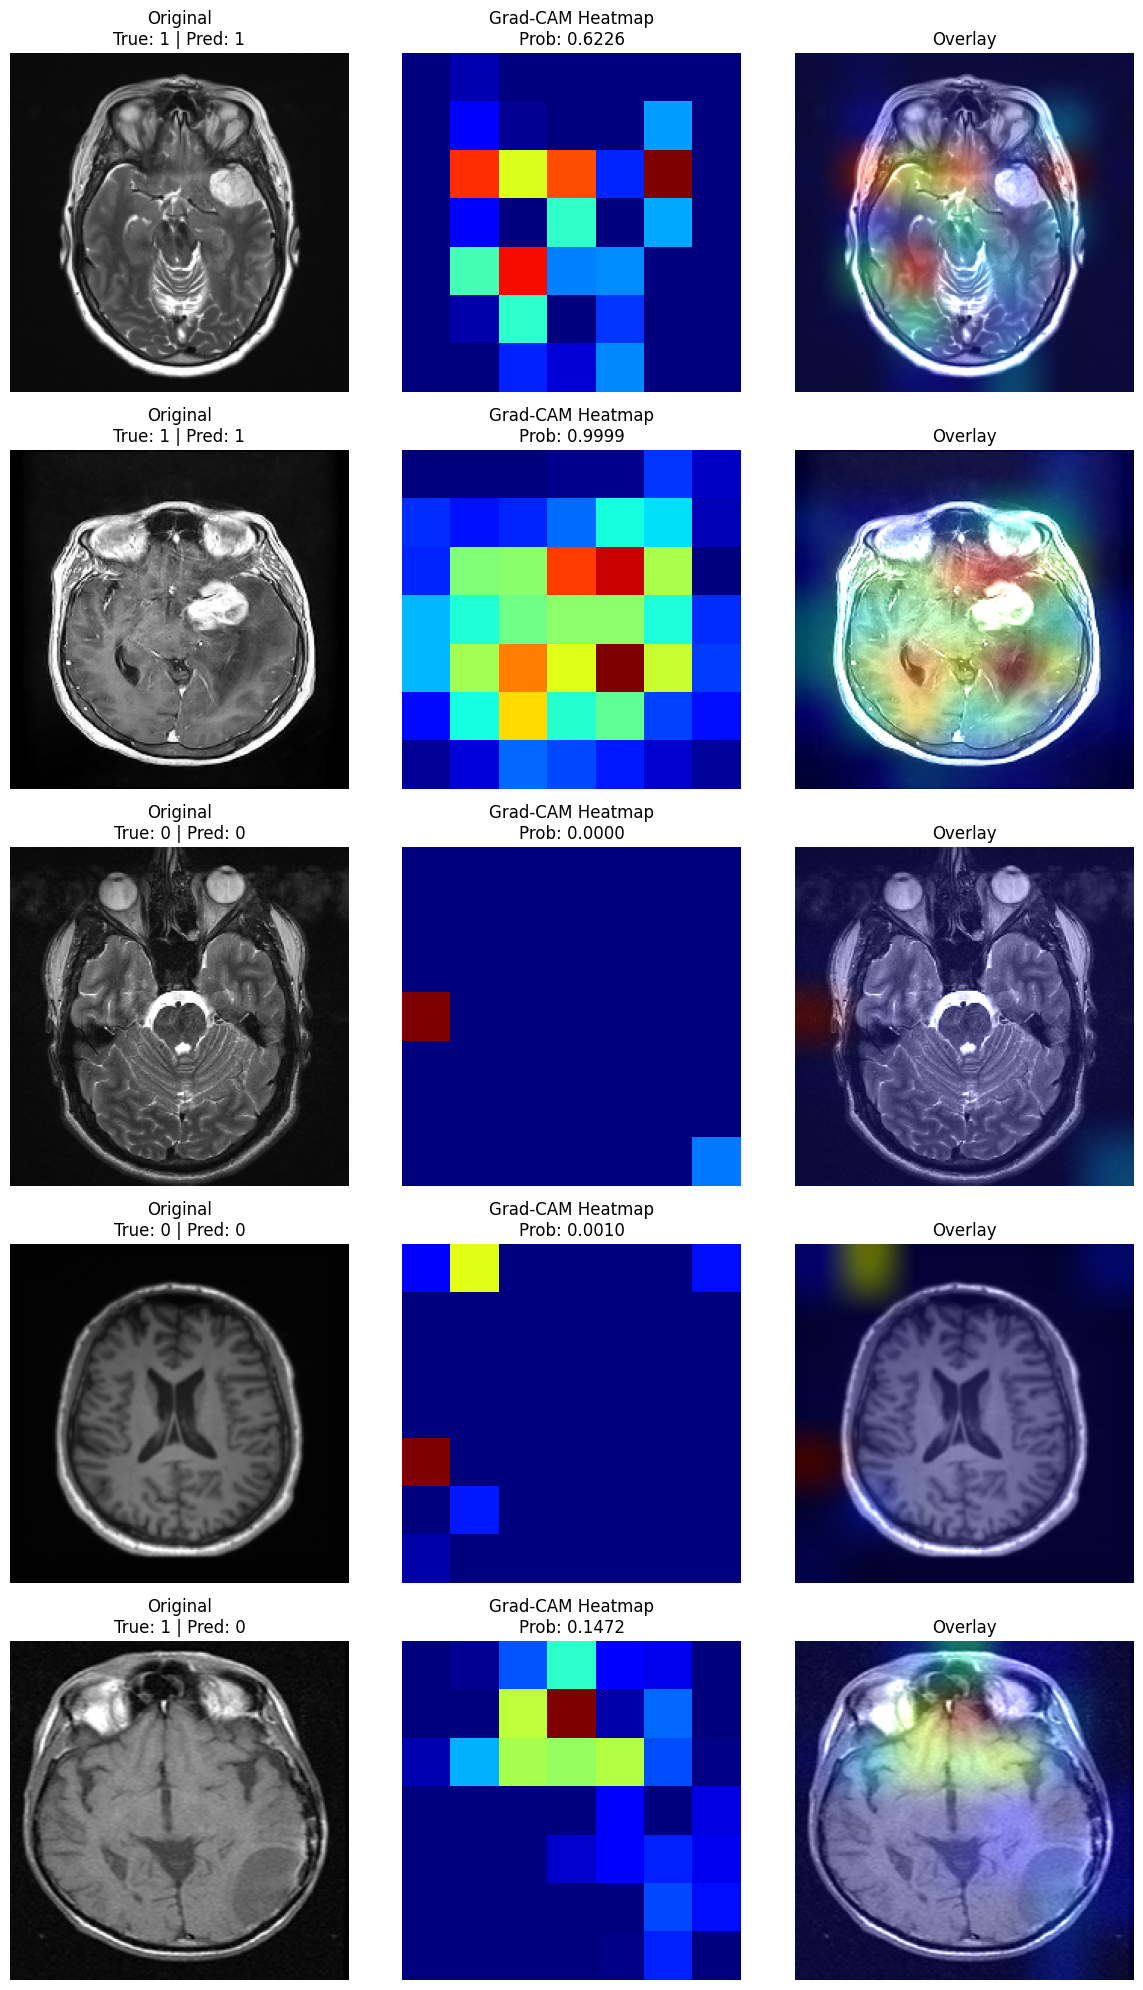

In [150]:
# 9. Generate Grad-CAM visualisations
fig, axes = plt.subplots(len(selected_indices), 3, figsize=(12, 4 * len(selected_indices)))

if len(selected_indices) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(selected_indices):
    img_path = test_filepaths[idx]
    true_label = mnet_y_true[idx]
    pred_label = mnet_y_pred[idx]
    pred_prob = mnet_y_prob[idx]

    img_array = load_and_preprocess_image(img_path, target_size=IMG_SIZE)

    # Generate heatmap using the fixed function
    heatmap = make_gradcam_heatmap(
        tf.cast(img_array, tf.float32),
        best_mobilenet_model,
        base_model_name="mobilenetv2_1.00_224",
        last_conv_layer_name=LAST_CONV_LAYER_NAME
    )

    original_img, heatmap_uint8, overlay_img = overlay_gradcam(img_path, heatmap, alpha=0.4, target_size=IMG_SIZE)

    axes[row, 0].imshow(original_img.astype("uint8"))
    axes[row, 0].set_title(f"Original\nTrue: {true_label} | Pred: {pred_label}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(heatmap, cmap="jet")
    axes[row, 1].set_title(f"Grad-CAM Heatmap\nProb: {pred_prob:.4f}")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(overlay_img)
    axes[row, 2].set_title("Overlay")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [153]:
gradcam_fig_path = os.path.join(base_path, "figures", "mobilenet_gradcam_explainer.png")
fig.savefig(gradcam_fig_path, bbox_inches="tight")
print("Grad-CAM visualization saved at:", gradcam_fig_path)

Grad-CAM visualization saved at: /content/drive/MyDrive/brain_tumour_project/figures/mobilenet_gradcam_explainer.png


In [154]:
notes_path_11 = os.path.join(base_path, "report_notes", "11_model_explainability.txt")

notes_text_11 = f"""
Step 11: Model Explainability with Grad-CAM

To ensure the model is making decisions based on relevant clinical features rather than noise, Grad-CAM (Gradient-weighted Class Activation Mapping) was applied to the MobileNetV2 model.

Methodology:
- Target Layer: 'out_relu' (the final convolutional layer of MobileNetV2).
- Process: Gradients of the output score were calculated with respect to the feature maps of the target layer. These gradients were pooled and used to weight the importance of specific spatial regions.
- Visualization: Heatmaps were generated and overlaid on original MRI scans for both correct classifications and errors.

Observations:
- For true positive cases, the heatmaps generally align with the spatial location of the tumour masses.
- For true negative cases, the activation is often more diffused or centered on anatomical structures of the brain without focal intensity.
- This step provides qualitative validation that the model has learned to extract meaningful pathological features from the MRI data.
"""

with open(notes_path_11, "w") as f:
    f.write(notes_text_11)

print("Notes_11 saved.")

Notes_11 saved.


In [151]:
gradcam_fig_path = os.path.join(base_path, "figures", "mobilenet_gradcam_explainer.png")
fig.savefig(gradcam_fig_path, bbox_inches="tight")
print("Grad-CAM visualization saved at:", gradcam_fig_path)

Grad-CAM visualization saved at: /content/drive/MyDrive/brain_tumour_project/figures/mobilenet_gradcam_explainer.png


In [152]:
notes_path_11 = os.path.join(base_path, "report_notes", "11_model_explainability.txt")

notes_text_11 = f"""
Step 11: Model Explainability with Grad-CAM

To ensure the model is making decisions based on relevant clinical features rather than noise, Grad-CAM (Gradient-weighted Class Activation Mapping) was applied to the MobileNetV2 model.

Methodology:
- Target Layer: 'out_relu' (the final convolutional layer of MobileNetV2).
- Process: Gradients of the output score were calculated with respect to the feature maps of the target layer. These gradients were pooled and used to weight the importance of specific spatial regions.
- Visualization: Heatmaps were generated and overlaid on original MRI scans for both correct classifications and errors.

Observations:
- For true positive cases, the heatmaps generally align with the spatial location of the tumour masses.
- For true negative cases, the activation is often more diffused or centered on anatomical structures of the brain without focal intensity.
- This step provides qualitative validation that the model has learned to extract meaningful pathological features from the MRI data.
"""

with open(notes_path_11, "w") as f:
    f.write(notes_text_11)

print("Notes_11 saved.")

Notes_11 saved.


In [155]:
# 12. Optional quick summary
print("Baseline false negatives:", 120)
print("MobileNetV2 false negatives:", 19)
print("MobileNetV2 recall:", mnet_recall)
print("Grad-CAM file:", gradcam_fig_path)

Baseline false negatives: 120
MobileNetV2 false negatives: 19
MobileNetV2 recall: 0.9535452322738386
Grad-CAM file: /content/drive/MyDrive/brain_tumour_project/figures/mobilenet_gradcam_explainer.png


In Grad-CAM was used to interpret the final MobileNetV2 classifier by highlighting image regions that contributed most strongly to each prediction. Example visualisations were generated for correctly classified tumour and non-tumour scans, along with a misclassified example where available. This helped assess whether the model focused on plausible anatomical regions rather than irrelevant background artefacts, thereby supporting the explainability requirement of the assignment.